In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("sleppyfish/aircraft-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 305M/305M [00:17<00:00, 18.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sleppyfish/aircraft-classification-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/sleppyfish/aircraft-classification-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/sleppyfish/aircraft-classification-dataset/versions/1):
['test', 'train']


### Dataset Overview

Let's examine the structure of the downloaded dataset and display some sample images from the `train` and `test` directories.

In [ ]:
print(f"Contents of the 'train' directory: {os.listdir(os.path.join(path, 'train'))}")
print(f"Contents of the 'test' directory: {os.listdir(os.path.join(path, 'test'))}")

Contents of the 'train' directory: ['9', '3', '7', '8', '4', '5', '6', '1', '2']
Contents of the 'test' directory: ['9', '3', '7', '8', '4', '5', '6', '1', '2']


### Displaying Sample Images

Now, let's visualize a few sample images from the 'train' and 'test' datasets to get a better understanding of the image content.


--- Sample Images from Training Dataset (/root/.cache/kagglehub/datasets/sleppyfish/aircraft-classification-dataset/versions/1/train) ---
Found 19569 images in /root/.cache/kagglehub/datasets/sleppyfish/aircraft-classification-dataset/versions/1/train. Displaying 6 samples:


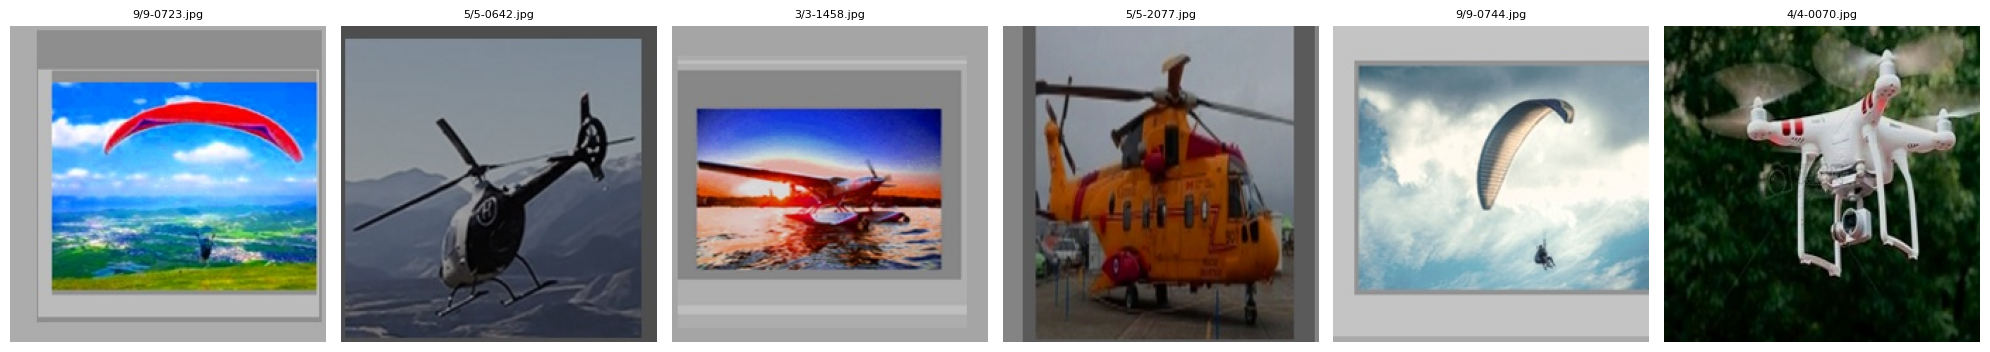


--- Sample Images from Test Dataset (/root/.cache/kagglehub/datasets/sleppyfish/aircraft-classification-dataset/versions/1/test) ---
Found 2305 images in /root/.cache/kagglehub/datasets/sleppyfish/aircraft-classification-dataset/versions/1/test. Displaying 6 samples:


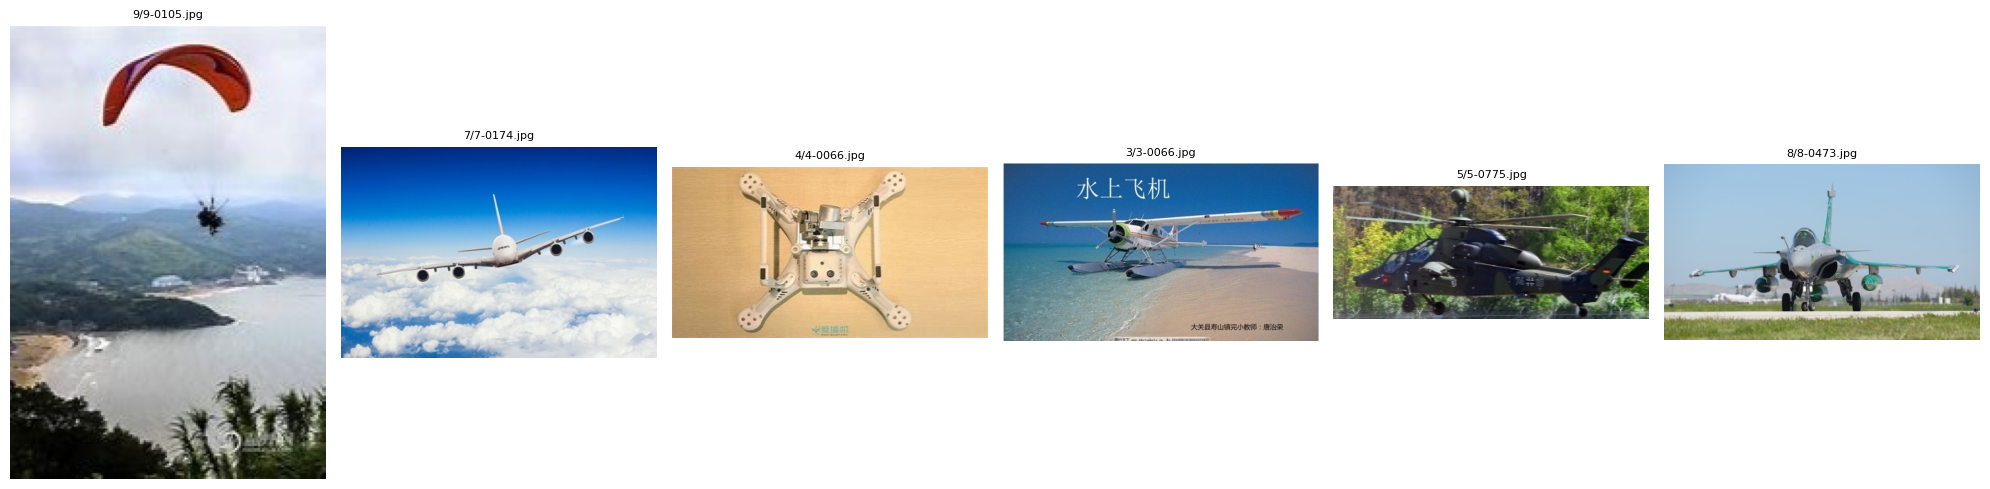

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig) # Close empty figure if no samples
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(os.path.dirname(img_path)) + '/' + os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Display sample images from the 'train' directory
train_path = os.path.join(path, 'train')
print(f"\n--- Sample Images from Training Dataset ({train_path}) ---")
display_sample_images(train_path)

# Display sample images from the 'test' directory
test_path = os.path.join(path, 'test')
print(f"\n--- Sample Images from Test Dataset ({test_path}) ---")
display_sample_images(test_path)

In [ ]:
import tensorflow as tf

# Check GPU availability
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
if len(tf.config.list_physical_devices('GPU')) > 0:
    print("GPU is active and ready for training.")
else:
    print("GPU not detected. Please enable GPU in Notebook Settings.")

Num GPUs Available:  1
GPU is active and ready for training.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Hyperparameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 9
EPOCHS = 10

# Data Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Build DenseNet Model
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Fine-tuning: Freeze base layers initially
for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Training
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator
)

Found 19569 images belonging to 9 classes.
Found 2305 images belonging to 9 classes.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/10
612/612 ━━━━━━━━━━━━━━━━━━━━ 316s 470ms/step - accuracy: 0.7223 - loss: 0.7955 - val_accuracy: 0.9106 - val_loss: 0.2561
Epoch 2/10
612/612 ━━━━━━━━━━━━━━━━━━━━ 254s 415ms/step - accuracy: 0.8091 - loss: 0.5405 - val_accuracy: 0.9180 - val_loss: 0.2470
Epoch 3/10
612/612 ━━━━━━━━━━━━━━━━━━━━ 251s 410ms/step - accuracy: 0.8303 - loss: 0.4829 - val_accuracy: 0.9319 - val_loss: 0.1980
Epoch 4/10
612/612 ━━━━━━━━━━━━━━━━━━━━ 258s 421ms/step - accuracy: 0.8428 - loss: 0.4405 - val_accuracy: 0.9371 - val_loss: 0.1788
Epoch 5/10
612/612 ━━━━━━━━━━━━━━━━━━━━ 254s 415ms/step - accuracy: 0.8571 - loss: 0.4118 - val_accuracy: 0.9388 - val_loss: 0.1788
Epoch 6/10
612/612 ━━━━━━━━━━━━━━━━━━━━ 254s 415ms/step - accuracy: 0.8632 - loss: 0.3892 - val_accuracy: 0.9475 - val_loss: 0.1608
Epoch 7/10
612/612 ━━━━━━━━━━━━━━━━━━━━ 261s 426ms/step - accuracy: 0.87

In [ ]:
# Summary of Training Results
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

# Display class mapping
print("\nClass mapping:", train_generator.class_indices)

73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.9488 - loss: 0.1535

Final Test Accuracy: 0.9488
Final Test Loss: 0.1535

Class mapping: {'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7, '9': 8}


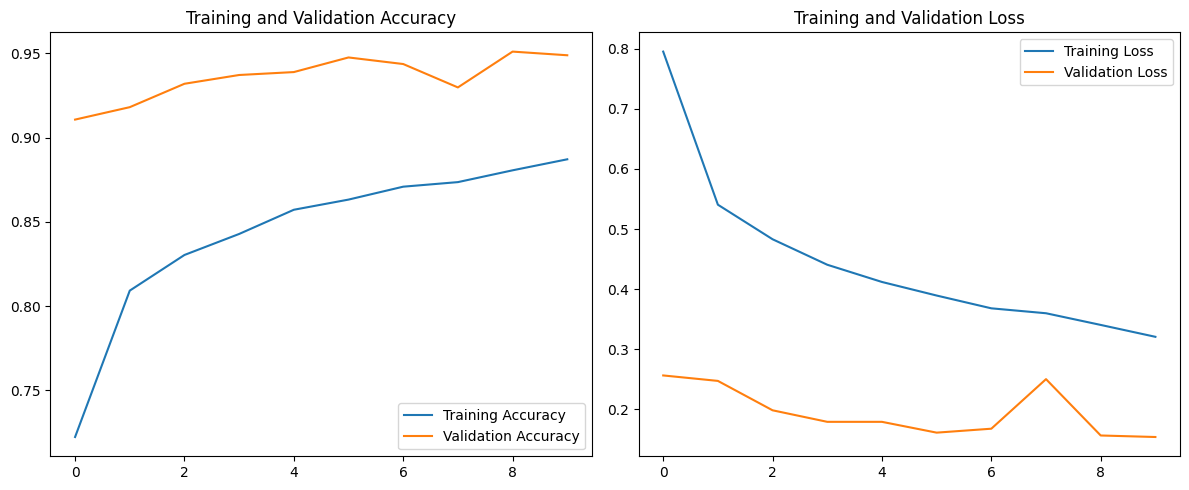

In [ ]:
# Visualization of Training History
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()